# **FireProtect - IoT based Smart Fire Detection System**

Machine Learning Models Training

## **Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Loading Dataset**

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Projects Datasets/IoT_Fire_Detection_System/synthetic_fire_dataset_final.csv')

In [3]:
df.head()

,GAS,HUMIDITY,TEMPERATURE,PIR,FLAME,FIRE_EXISTENCE
0,288,78.354169,25.604131,0,0,NO FIRE
1,253,58.825483,30.366834,1,1,FALSE FIRE ALARM
2,2156,50.479364,35.588050,1,0,FALSE FIRE ALARM
3,856,54.958529,32.897181,0,0,NO FIRE
4,1272,70.481274,28.309841,1,1,FALSE FIRE ALARM


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   GAS             20000 non-null  int64  
 1   HUMIDITY        20000 non-null  float64
 2   TEMPERATURE     20000 non-null  float64
 3   PIR             20000 non-null  int64  
 4   FLAME           20000 non-null  int64  
 5   FIRE_EXISTENCE  20000 non-null  object 
dtypes: float64(2), int64(3), object(1)
memory usage: 937.6+ KB


In [5]:
print(df["FIRE_EXISTENCE"].value_counts())

FIRE_EXISTENCE
FALSE FIRE ALARM     13492
NO FIRE               3689
ACTUAL FIRE ALARM     2819
Name: count, dtype: int64


## **Data Visualization**

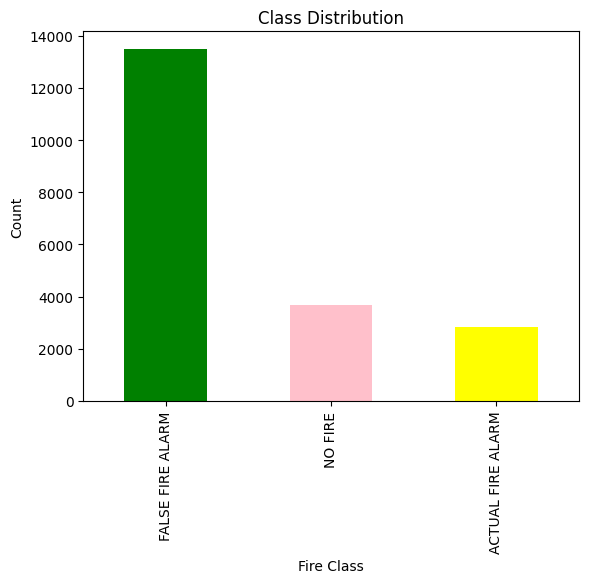

In [6]:
# Class Distribution Plot
df["FIRE_EXISTENCE"].value_counts().plot(
    kind='bar',
    color=['green', 'pink', 'yellow']   # adjust based on number of classes
)

plt.title("Class Distribution")
plt.xlabel("Fire Class")
plt.ylabel("Count")
plt.show()

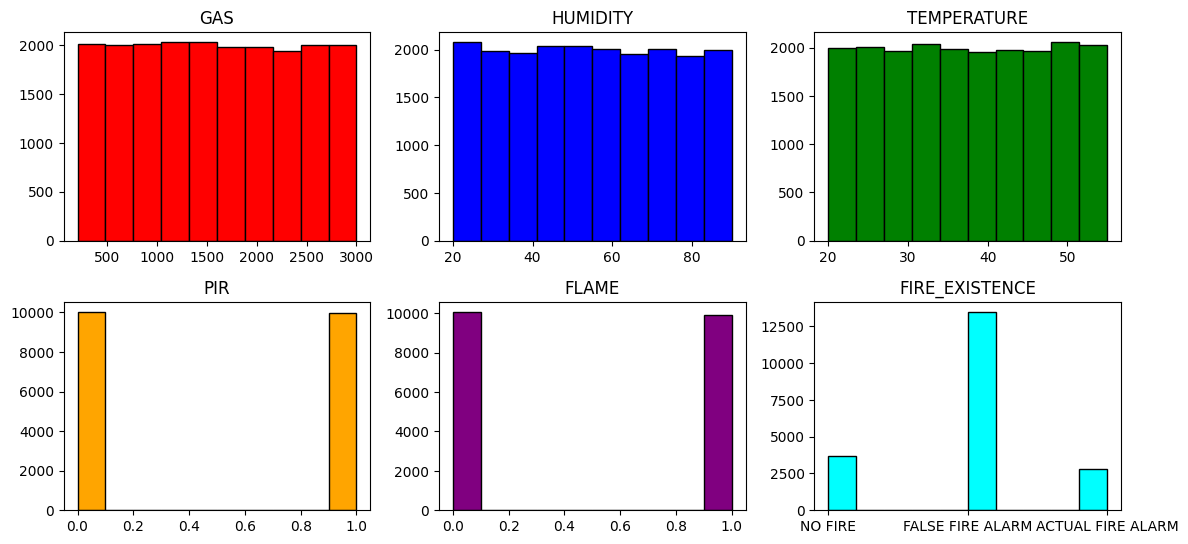

In [7]:
# Feature Distributions Plot
colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan']

df_columns = df.columns
fig, axes = plt.subplots(nrows=(len(df_columns)//3)+1, ncols=3, figsize=(12,8))

axes = axes.flatten()

for i, col in enumerate(df_columns):
    axes[i].hist(df[col], color=colors[i % len(colors)], edgecolor='black')
    axes[i].set_title(col)

# Remove extra empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

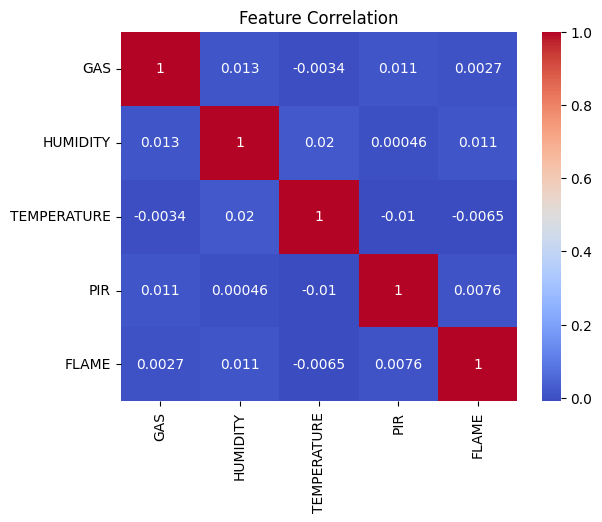

In [8]:
# Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

## **Data Preprocessing**

In [9]:
# Encoding target labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["FIRE_EXISTENCE"] = le.fit_transform(df["FIRE_EXISTENCE"])

In [10]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

{'ACTUAL FIRE ALARM': np.int64(0), 'FALSE FIRE ALARM': np.int64(1), 'NO FIRE': np.int64(2)}


In [11]:
# Splitting in X & y Features
X = df.drop("FIRE_EXISTENCE", axis=1)
y = df["FIRE_EXISTENCE"]

In [12]:
# Train - Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Applying SMOTE to cater to the imbalanced data

In [13]:
print(df["FIRE_EXISTENCE"].value_counts())

FIRE_EXISTENCE
1    13492
2     3689
0     2819
Name: count, dtype: int64


In [14]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

In [15]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [16]:
print(pd.Series(y_train_smote).value_counts())

FIRE_EXISTENCE
1    10794
0    10794
2    10794
Name: count, dtype: int64


Feature Scaling

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [18]:
X_train_smote = scaler.fit_transform(X_train_smote)
X_test = scaler.transform(X_test)

## **Model Training**

Random Forest ML Model

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

In [20]:
rf_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(max_depth=8, random_state=42)

Decision Tree ML Model

In [21]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=4,   # keep small for deployment
    random_state=42
)

In [22]:
dt_model.fit(X_train_smote, y_train_smote)

DecisionTreeClassifier(max_depth=4, random_state=42)

## **Making Predictions**

In [23]:
rf_pred = rf_model.predict(X_test)
dt_pred = dt_model.predict(X_test)

## **Evaluation Metrics**

In [24]:
# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print("RF Precision:", precision_score(y_test, rf_pred, average='weighted'))
print("RF Recall:", recall_score(y_test, rf_pred, average='weighted'))
print("RF F1:", f1_score(y_test, rf_pred, average='weighted'))

RF Accuracy: 1.0
RF Precision: 1.0
RF Recall: 1.0
RF F1: 1.0


In [25]:
# Accuracy
from sklearn.metrics import accuracy_score

print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print("DT Accuracy:", accuracy_score(y_test, dt_pred))

RF Accuracy: 1.0
DT Accuracy: 1.0


In [26]:
# F1 Score
from sklearn.metrics import f1_score

print("RF F1:", f1_score(y_test, rf_pred, average='weighted'))
print("DT F1:", f1_score(y_test, dt_pred, average='weighted'))

RF F1: 1.0
DT F1: 1.0


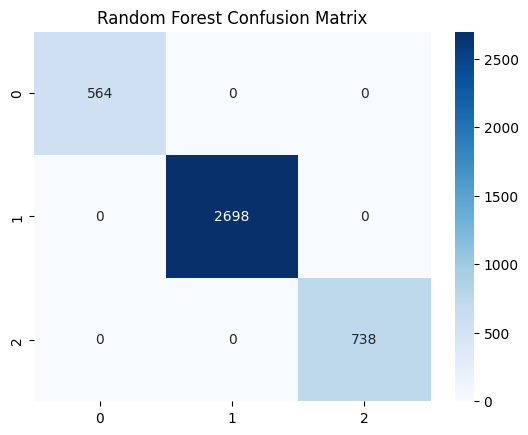

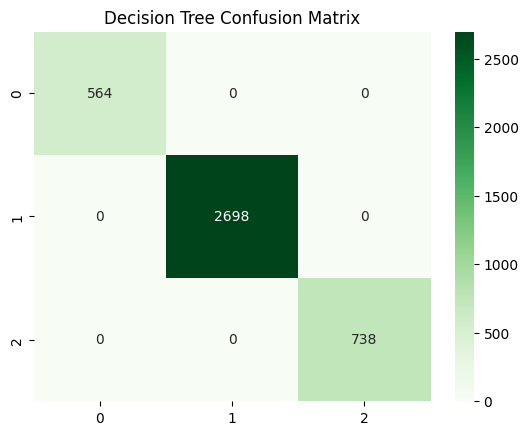

In [27]:
# Confusion Metrics
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Random Forest
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

# Decision Tree
sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [28]:
# Classification Report
from sklearn.metrics import classification_report

print("Random Forest Report:\n", classification_report(y_test, rf_pred))
print("Decision Tree Report:\n", classification_report(y_test, dt_pred))

Random Forest Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       564
           1       1.00      1.00      1.00      2698
           2       1.00      1.00      1.00       738

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

Decision Tree Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       564
           1       1.00      1.00      1.00      2698
           2       1.00      1.00      1.00       738

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



## **Result Visualization**

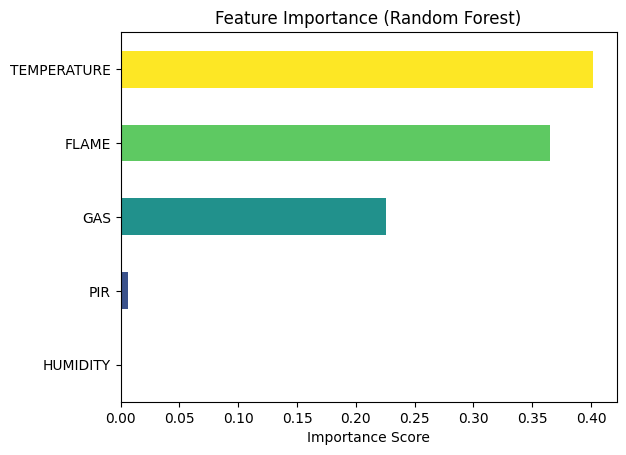

In [29]:
# Feature Importance of Random Forest
importances = rf_model.feature_importances_
features = pd.Series(importances, index=X.columns)

features_sorted = features.sort_values()

# Generate colors automatically
colors = plt.cm.viridis(np.linspace(0, 1, len(features_sorted)))

features_sorted.plot(kind='barh', color=colors)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

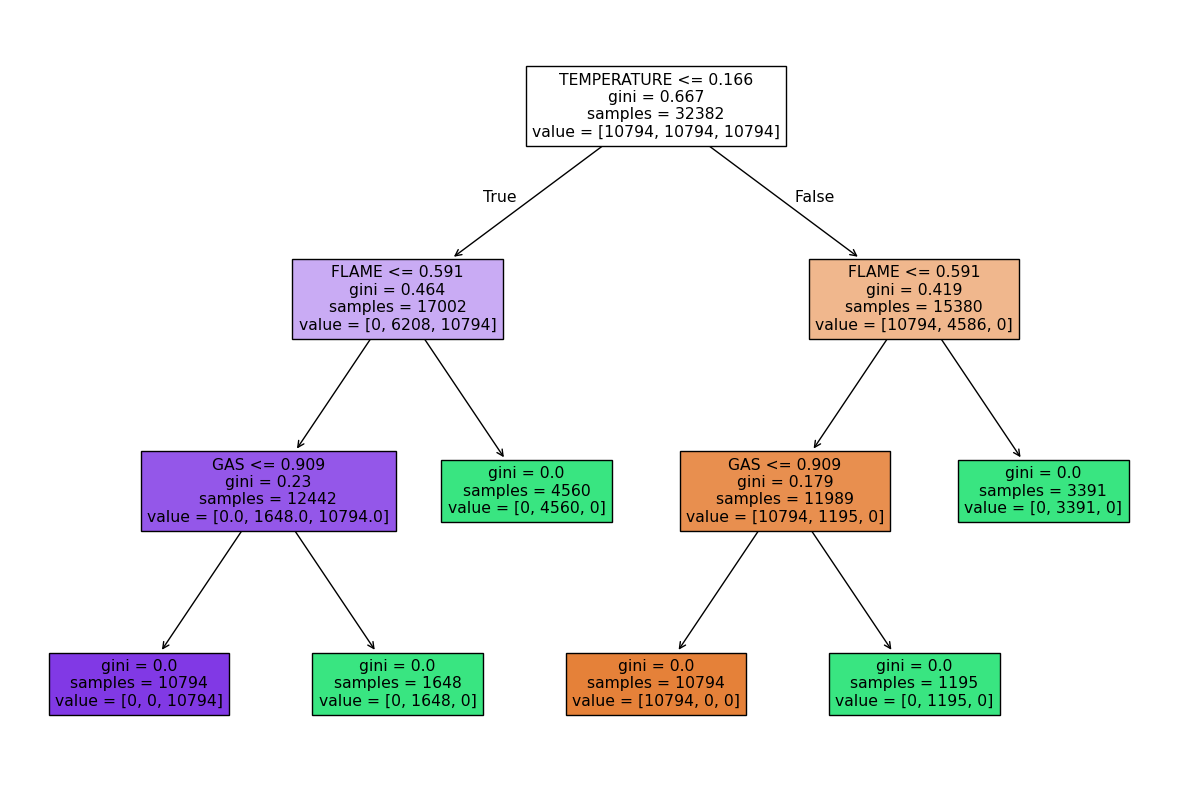

In [30]:
# Decision Tree Visualization
from sklearn.tree import plot_tree

plt.figure(figsize=(15,10))
plot_tree(dt_model, feature_names=X.columns, filled=True)
plt.show()

In [31]:
# Extract Rules
from sklearn.tree import export_text

rules = export_text(dt_model, feature_names=list(X.columns))
print(rules)

|--- TEMPERATURE <= 0.17
|   |--- FLAME <= 0.59
|   |   |--- GAS <= 0.91
|   |   |   |--- class: 2
|   |   |--- GAS >  0.91
|   |   |   |--- class: 1
|   |--- FLAME >  0.59
|   |   |--- class: 1
|--- TEMPERATURE >  0.17
|   |--- FLAME <= 0.59
|   |   |--- GAS <= 0.91
|   |   |   |--- class: 0
|   |   |--- GAS >  0.91
|   |   |   |--- class: 1
|   |--- FLAME >  0.59
|   |   |--- class: 1



In [32]:
# Cross Validation
from sklearn.model_selection import cross_val_score

rf_scores = cross_val_score(rf_model, X_train_smote, y_train_smote, cv=5)
dt_scores = cross_val_score(dt_model, X_train_smote, y_train_smote, cv=5)

print("RF CV Score:", rf_scores.mean())
print("DT CV Score:", dt_scores.mean())

RF CV Score: 0.9997220935618343
DT CV Score: 0.9997220935618343


## **Saving Models**

In [33]:
import pickle

In [34]:
with open("rf_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

In [35]:
with open("dt_model.pkl", "wb") as f:
    pickle.dump(dt_model, f)

In [36]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [37]:
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

In [38]:
# Testing full pipeline
# Load all
rf_model = pickle.load(open("rf_model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))
le = pickle.load(open("label_encoder.pkl", "rb"))

# Example input
sample = [[1500, 60, 45, 1, 1]]  # GAS, HUMIDITY, TEMP, PIR, FLAME

sample = scaler.transform(sample)

pred = rf_model.predict(sample)

print("Prediction:", le.inverse_transform(pred))

Prediction: ['FALSE FIRE ALARM']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
